In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = "loan_prediction.csv"
train = pd.read_csv(train)
test = "loan_prediction.csv"
test = pd.read_csv(test)

In [ ]:
train.shape

(614, 14)

In [ ]:
test.shape

(614, 14)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         614 non-null    int64  
 1   Loan_ID            614 non-null    object 
 2   Gender             601 non-null    object 
 3   Married            611 non-null    object 
 4   Dependents         599 non-null    object 
 5   Education          614 non-null    object 
 6   Self_Employed      582 non-null    object 
 7   ApplicantIncome    614 non-null    int64  
 8   CoapplicantIncome  614 non-null    float64
 9   LoanAmount         592 non-null    float64
 10  Loan_Amount_Term   600 non-null    float64
 11  Credit_History     564 non-null    float64
 12  Property_Area      614 non-null    object 
 13  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(2), object(8)
memory usage: 67.3+ KB


In [ ]:
train.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
data = pd.concat([train,test])

In [ ]:
data.drop('Loan_ID', inplace=True, axis='columns')

In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
Gender,26
Married,6
Dependents,30
Education,0
Self_Employed,64
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,44
Loan_Amount_Term,28


In [ ]:
data['Gender'].fillna(data['Gender'].mode()[0], inplace = True)
data['Married'].fillna(data['Married'].mode()[0], inplace = True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace = True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace = True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace = True)

In [ ]:
#Filling missing values of LoanAmount and Loan_Amount_Term
data1 = data.loc[:,['LoanAmount','Loan_Amount_Term']]

from sklearn.ensemble import RandomForestRegressor

imp = IterativeImputer(RandomForestRegressor(), max_iter=1000, random_state=0)
data1 = pd.DataFrame(imp.fit_transform(data1), columns=data1.columns)

data['LoanAmount'] = data1['LoanAmount']
data['Loan_Amount_Term'] = data1['Loan_Amount_Term']

In [ ]:
data['Gender'] = data['Gender'].map({'Male':0,'Female':1}).astype(int)
data['Married'] = data['Married'].map({'No':0,'Yes':1}).astype(int)
data['Education'] = data['Education'].map({'Not Graduate':0,'Graduate':1}).astype(int)
data['Self_Employed'] = data['Self_Employed'].map({'No':0,'Yes':1}).astype(int)
data['Credit_History'] = data['Credit_History'].astype(int)

In [ ]:
data['Property_Area'] = data['Property_Area'].map({'Urban':0,'Rural':1, 'Semiurban':2}).astype(int)
data['Dependents'] = data['Dependents'].map({'0':0, '1':1, '2':2, '3+':3})

In [ ]:
data['Total_Income'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data.drop(['ApplicantIncome', 'CoapplicantIncome'], axis='columns', inplace=True)

In [ ]:
# Splitting the data to new_train and new_test so that we can perform EDA.
new_train = data.iloc[:614]
new_test = data.iloc[614:]

In [ ]:
# Mapping ‘N’ to 0 and ‘Y’ to 1
new_train['Loan_Status'] = new_train['Loan_Status'].map({'N':0,'Y':1}).astype(int)

<Axes: xlabel='Dependents', ylabel='count'>

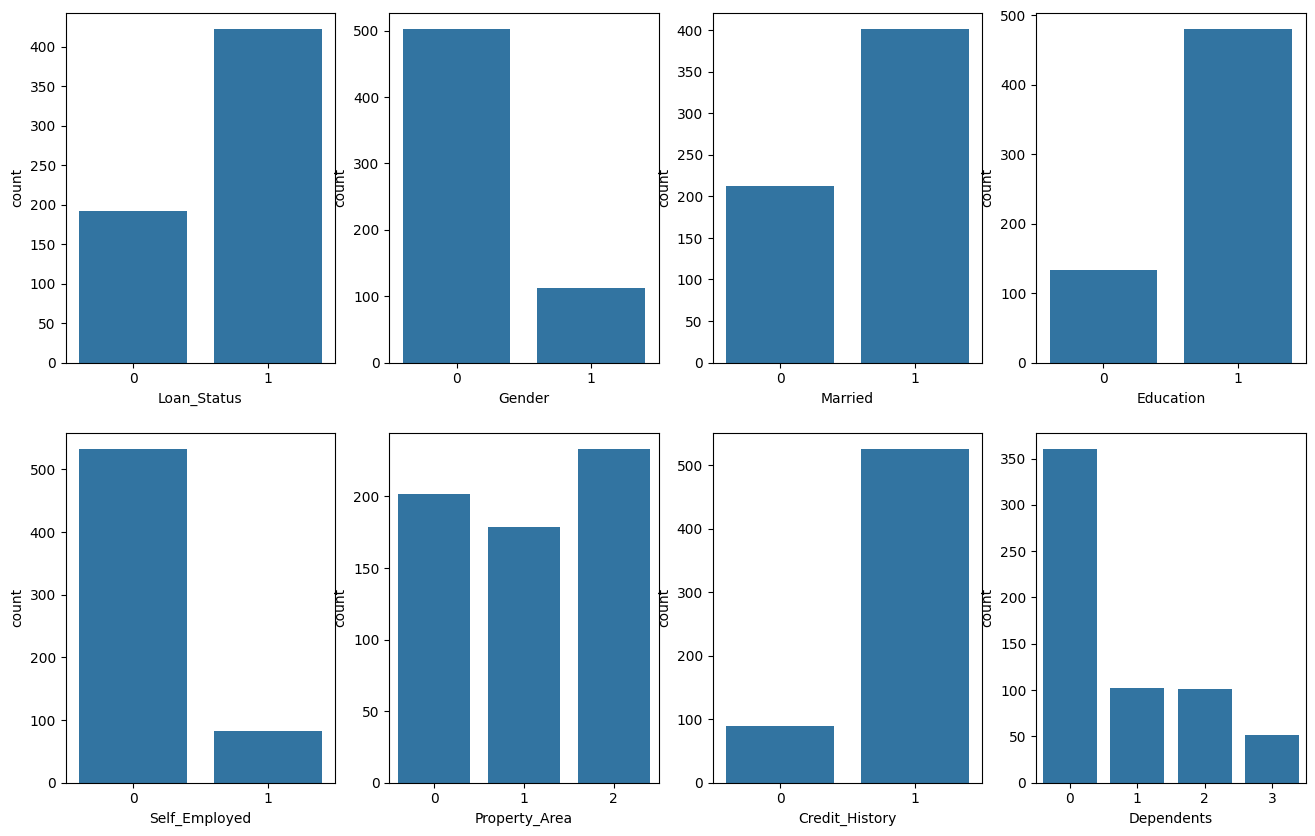

In [ ]:
fig,ax = plt.subplots(2,4,figsize=(16,10))
sns.countplot(x='Loan_Status', data = new_train, ax=ax[0][0])
sns.countplot(x='Gender', data = new_train, ax=ax[0][1])
sns.countplot(x='Married', data = new_train, ax=ax[0][2])
sns.countplot(x='Education', data = new_train, ax=ax[0][3])
sns.countplot(x='Self_Employed', data = new_train, ax=ax[1][0])
sns.countplot(x='Property_Area', data = new_train, ax=ax[1][1])
sns.countplot(x='Credit_History', data = new_train, ax=ax[1][2])
sns.countplot(x='Dependents', data = new_train, ax=ax[1][3])

<Axes: xlabel='Loan_Status', ylabel='Total_Income'>

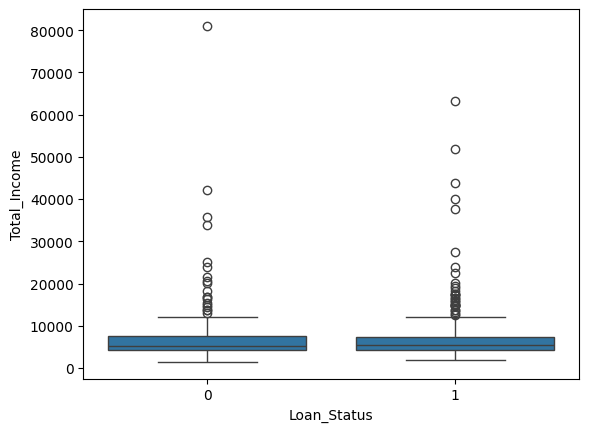

In [ ]:
sns.boxplot(x='Loan_Status', y='Total_Income', data=new_train)

<Axes: xlabel='Loan_Status', ylabel='Total_Income'>

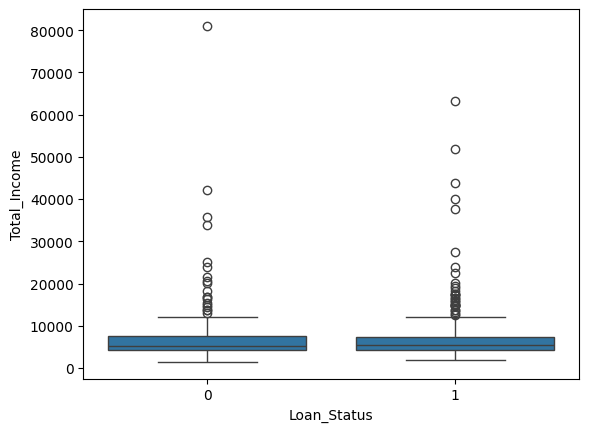

In [ ]:
sns.boxplot(x='Loan_Status', y='Total_Income', data=new_train)

<Axes: >

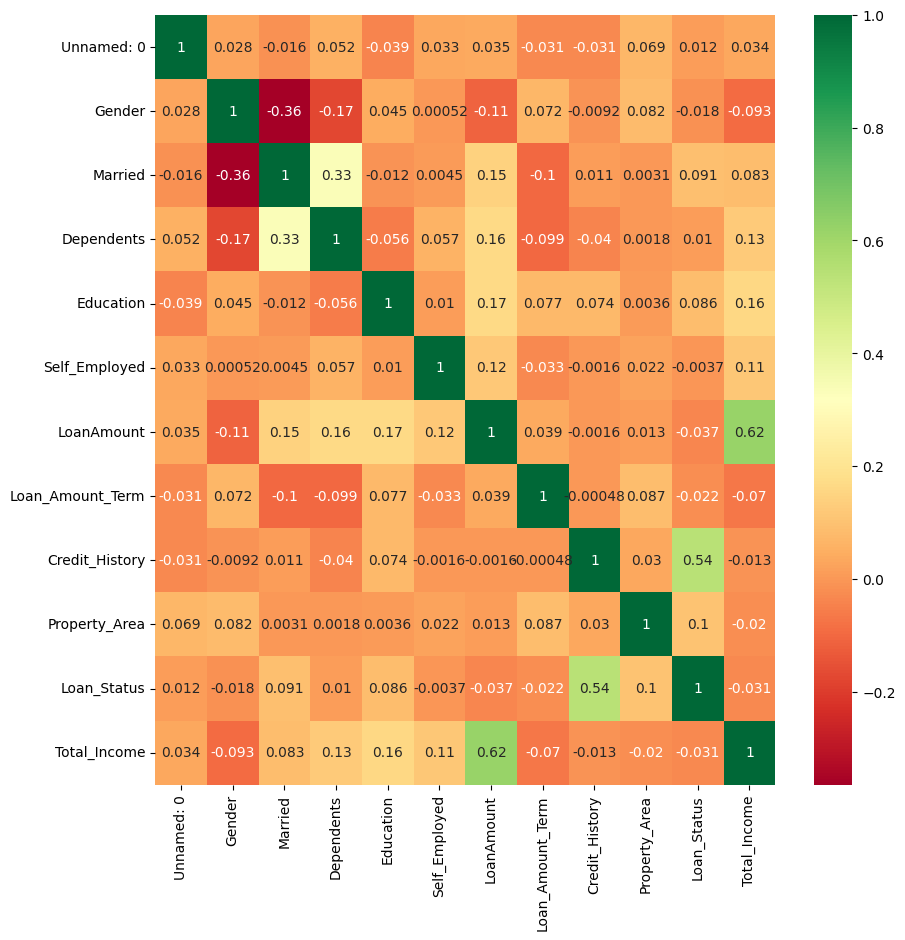

In [ ]:
# Correlation matrix
plt.figure(figsize = (10,10))
correlation_matrix = new_train.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn')

In [ ]:
# Creating X (input variables) and Y (Target Variable) from the new_train data.
x = new_train.drop('Loan_Status', axis='columns')
y = new_train['Loan_Status']

In [ ]:
# Using train test split on the training data for validation
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=3)

In [ ]:
#Building the model using DecisonTree
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
dtree_pred = dtree.predict(X_test)
# Classification report and confusion matrix of the decision tree model
print(confusion_matrix(y_test, dtree_pred))
print(classification_report(y_test,dtree_pred))

[[ 29  16]
 [ 23 117]]
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        45
           1       0.88      0.84      0.86       140

    accuracy                           0.79       185
   macro avg       0.72      0.74      0.73       185
weighted avg       0.80      0.79      0.79       185



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rfc = RandomForestClassifier(n_estimators=200)
rfc.fit(X_train, y_train)

# Getting the accuracy score for Random Forest
rfc_pred = rfc.predict(X_test)
print("Accuracy_Score =", format(metrics.accuracy_score(y_test, rfc_pred)))

Accuracy_Score = 0.8486486486486486


In [ ]:
# Classification report and confusion matrix of the Random Forest model
print(confusion_matrix(y_test, rfc_pred))
print(classification_report(y_test,rfc_pred))

[[ 25  20]
 [  8 132]]
              precision    recall  f1-score   support

           0       0.76      0.56      0.64        45
           1       0.87      0.94      0.90       140

    accuracy                           0.85       185
   macro avg       0.81      0.75      0.77       185
weighted avg       0.84      0.85      0.84       185



In [ ]:
#Building the model using LogisticRegression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
logreg.predict(X_test)

# Getting the accuracy score for Logistic Regression
logreg_pred = logreg.predict(X_test)
print("Accuracy_Score =", format(metrics.accuracy_score(y_test, logreg_pred)))

Accuracy_Score = 0.8432432432432433


In [ ]:
#Get predictions of Random Forest and Logistic Regression models in the form of probability values
y_lg_prob = logreg.predict_proba(X_test)[:,1]
y_rfc_prob = rfc.predict_proba(X_test)[:,1]

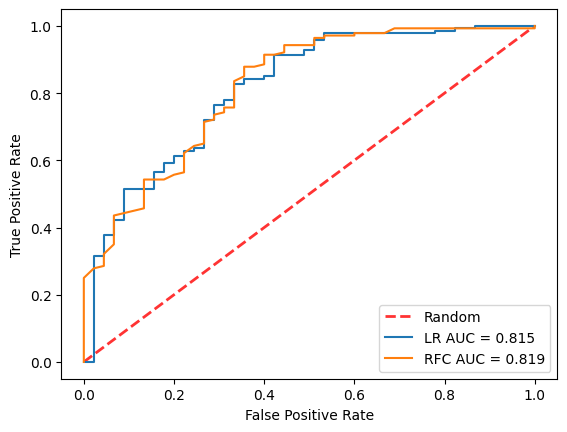

In [ ]:
#For Logistic Regression
fpr, tpr, _ = metrics.roc_curve(y_test,y_lg_prob)
auc = metrics.roc_auc_score(y_test, y_lg_prob)

#For Random Forest
fpr1, tpr1, _1 = metrics.roc_curve(y_test,y_rfc_prob)
auc1 = metrics.roc_auc_score(y_test, y_rfc_prob)

#create ROC curve
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',label='Random', alpha=.8)
plt.plot(fpr,tpr,label="LR AUC = "+str(round(auc,3)))
plt.plot(fpr1,tpr1,label="RFC AUC = "+str(round(auc1,3)))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

<Axes: >

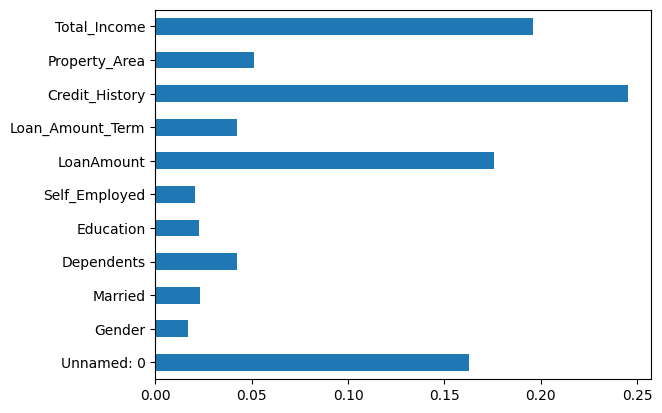

In [ ]:
# Getting feature importances for Random Forest model
(pd.Series(rfc.feature_importances_, index=X_train.columns).plot(kind='barh'))

In [ ]:
X_final_test = new_test.drop('Loan_Status', axis='columns')
logreg_final_pred = logreg.predict(X_final_test)
print("First 10 Loan Status Predictions for the test set:")
print(logreg_final_pred[:10])

First 10 Loan Status Predictions for the test set:
[1 1 1 1 1 1 1 0 1 1]


### Enter Loan Application Details for Prediction

In [ ]:
print("Please provide the following details for loan approval prediction:")

def predict_loan_approval(Gender, Married, Dependents, Education, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Total_Income):

    input_data = pd.DataFrame([[0, Gender, Married, Dependents, Education, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Total_Income]],
                                columns=['Unnamed: 0', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Total_Income'])

    prediction = logreg.predict(input_data)

    if prediction[0] == 1:
        return "Approved"
    else:
        return "Not Approved"

user_gender = input("Gender (Male/Female): ").strip().lower()
if user_gender == 'male':
    user_gender_encoded = 0
elif user_gender == 'female':
    user_gender_encoded = 1
else:
    print("Invalid Gender input. Using default Male (0).")
    user_gender_encoded = 0

user_married = input("Married (Yes/No): ").strip().lower()
if user_married == 'no':
    user_married_encoded = 0
elif user_married == 'yes':
    user_married_encoded = 1
else:
    print("Invalid Married input. Using default No (0).")
    user_married_encoded = 0

user_dependents = input("Dependents (0, 1, 2, or 3+): ").strip()
if user_dependents == '3+':
    user_dependents_encoded = 3
else:
    try:
        user_dependents_encoded = int(user_dependents)
    except ValueError:
        print("Invalid Dependents input. Using default 0.")
        user_dependents_encoded = 0

user_education = input("Education (Graduate/Not Graduate): ").strip().lower()
if user_education == 'not graduate':
    user_education_encoded = 0
elif user_education == 'graduate':
    user_education_encoded = 1
else:
    print("Invalid Education input. Using default Graduate (1).")
    user_education_encoded = 1

user_self_employed = input("Self Employed (Yes/No): ").strip().lower()
if user_self_employed == 'no':
    user_self_employed_encoded = 0
elif user_self_employed == 'yes':
    user_self_employed_encoded = 1
else:
    print("Invalid Self Employed input. Using default No (0).")
    user_self_employed_encoded = 0

while True:
    try:
        user_loanamount = float(input("Loan Amount (e.g., 150000): "))
        break
    except ValueError:
        print("Invalid input. Please enter a numerical value for Loan Amount.")

while True:
    try:
        user_loan_amount_term = float(input("Loan Amount Term in months (e.g., 360.0): "))
        break
    except ValueError:
        print("Invalid input. Please enter a numerical value for Loan Amount Term.")

while True:
    try:
        user_credit_history = float(input("Credit History (1.0 for Yes, 0.0 for No): "))
        if user_credit_history not in [0.0, 1.0]:
            raise ValueError
        break
    except ValueError:
        print("Invalid input. Please enter 1.0 or 0.0 for Credit History.")

user_property_area = input("Property Area (Urban/Rural/Semiurban): ").strip().lower()
if user_property_area == 'urban':
    user_property_area_encoded = 0
elif user_property_area == 'rural':
    user_property_area_encoded = 1
elif user_property_area == 'semiurban':
    user_property_area_encoded = 2
else:
    print("Invalid Property Area input. Using default Urban (0).")
    user_property_area_encoded = 0

while True:
    try:
        user_total_income = float(input("Total Income (Applicant Income + Coapplicant Income, e.g., 7000.0): "))
        break
    except ValueError:
        print("Invalid input. Please enter a numerical value for Total Income.")

final_prediction = predict_loan_approval(
    Gender=user_gender_encoded,
    Married=user_married_encoded,
    Dependents=user_dependents_encoded,
    Education=user_education_encoded,
    Self_Employed=user_self_employed_encoded,
    LoanAmount=user_loanamount,
    Loan_Amount_Term=user_loan_amount_term,
    Credit_History=user_credit_history,
    Property_Area=user_property_area_encoded,
    Total_Income=user_total_income
)
print(f"\nBased on the provided details, the loan status is: {final_prediction}")

Please provide the following details for loan approval prediction:
Gender (Male/Female): Male
Married (Yes/No): Yes
Dependents (0, 1, 2, or 3+): 0
Education (Graduate/Not Graduate): Graduate
Self Employed (Yes/No): Yes
Loan Amount (e.g., 150000): 66
Loan Amount Term in months (e.g., 360.0): 360
Credit History (1.0 for Yes, 0.0 for No): 1
Property Area (Urban/Rural/Semiurban): Urban
Total Income (Applicant Income + Coapplicant Income, e.g., 7000.0): 3000

Based on the provided details, the loan status is: Approved
